In [1]:
import geopandas as gpd
import random
from shapely.geometry import Point

In [2]:
gdf = gpd.read_file("../data/gis/mavfa-fs-3000_zone.shp")

# 2. Imposta CRS (se manca)
gdf = gdf.set_crs("EPSG:4326")

# (opzionale ma consigliato) lavora in metri
#gdf = gdf.to_crs("EPSG:3857")

In [3]:
gdf

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
0,SM,Repubblica di San Marino,99.0,Manual insert,3000.0,43.938325,12.463315,"POLYGON ((12.41168 43.93891, 12.41032 43.93991..."
1,VA,Città del Vaticano,58.0,Manual insert,3000.0,41.903445,12.453023,"POLYGON ((12.44658 41.90241, 12.44682 41.90224..."
2,5010,Napoli - 11,63.0,napoli,3000.0,40.847021,14.267001,"POLYGON ((14.2758 40.84482, 14.27442 40.84454,..."
3,10010041002,Varallo,2.0,CESPI,3000.0,45.820946,8.246350,"POLYGON ((8.16704 45.77608, 8.16682 45.7763, 8..."
4,10010041003,Balmuccia,2.0,CESPI,3000.0,45.772575,8.038943,"POLYGON ((8.06444 45.79512, 8.0646 45.79521, 8..."
...,...,...,...,...,...,...,...,...
2975,3049,Latino,58.0,roma,3000.0,41.875260,12.521160,"POLYGON ((12.52275 41.88904, 12.5228 41.88901,..."
2976,6020,Padova,15.0,milano,3000.0,45.504990,9.224978,"POLYGON ((9.23631 45.48613, 9.23473 45.48612, ..."
2977,6021,Buenos Aires - Venezia,15.0,milano,3000.0,45.477025,9.214489,"POLYGON ((9.21526 45.48645, 9.21597 45.4861, 9..."
2978,6040,Parco delle Abbazie,15.0,milano,3000.0,45.418270,9.197160,"POLYGON ((9.21048 45.39686, 9.21038 45.39684, ..."


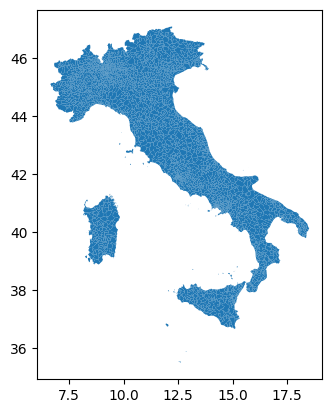

In [4]:
gdf.plot();

In [4]:
firenze_centro_storico = gdf[gdf.zone_name == 'Firenze Centro Storico']
#firenze_centro_storico = firenze_centro_storico.to_crs("EPSG:4326")
firenze_centro_storico

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2657,1009006000,Firenze Centro Storico,48.0,citta_metro,3000.0,43.761575,11.233814,"POLYGON ((11.30134 43.76433, 11.30338 43.76379..."


In [7]:
gdf[gdf.area_id == '1009006000']

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2657,1009006000,Firenze Centro Storico,48.0,citta_metro,3000.0,43.761575,11.233814,"POLYGON ((11.30134 43.76433, 11.30338 43.76379..."


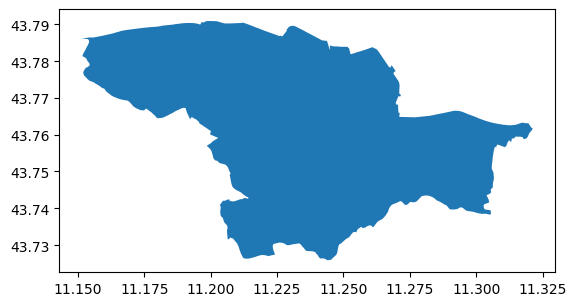

In [19]:
firenze_centro_storico.plot();

In [20]:
gdf[gdf.zone_name == 'Campo di Marte']

,area_id,zone_name,cod_pro,origin,layer_id,lat,lon,geometry
2659,1009006002,Campo di Marte,48.0,citta_metro,3000.0,43.789761,11.293229,"POLYGON ((11.28752 43.83132, 11.28753 43.83125..."


In [21]:

# 4. Funzione per punto casuale
def random_point_in_polygon(polygon):
    minx, miny, maxx, maxy = polygon.bounds
    
    while True:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        p = Point(x, y)
        if polygon.contains(p):
            return p

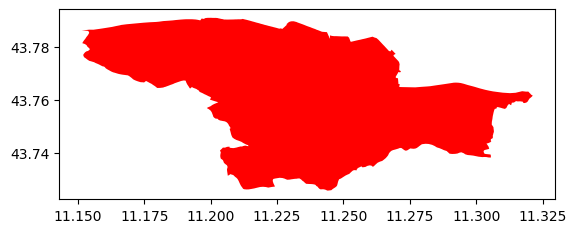

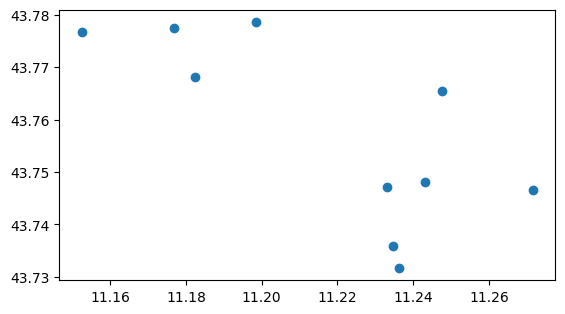

In [22]:

# 3. Scegli una geometria (es: zona trovata prima)
geom = firenze_centro_storico.geometry.iloc[0]
# 5. Genera N punti
N = 10
points = [random_point_in_polygon(geom) for _ in range(N)]

# 6. Crea GeoDataFrame dei punti
points_gdf = gpd.GeoDataFrame(geometry=points, crs=gdf.crs)

# 7. Visualizza
#ax = gdf.plot(color="lightgrey", figsize=(6,6))
gpd.GeoSeries([geom]).plot( color="red")
points_gdf.plot();

In [23]:
print(geom.centroid)

POINT (11.23381369382768 43.76157537950424)


In [24]:
print(geom.representative_point())

POINT (11.256567034557314 43.7582927738754)


# Some attempts on different zones

In [2]:
gdf = gpd.read_file("../data/zonizzazione/Sez censimento Toscana_riparate.shp")

# 2. Imposta CRS (se manca)
#gdf = gdf.set_crs("EPSG:4326")

# (opzionale ma consigliato) lavora in metri
#gdf = gdf.to_crs("EPSG:3857")

In [20]:
gdf

,COD_REG,COD_UTS,PRO_COM,SEZ21,SEZ21_ID,COD_TIPO_S,TIPO_LOC,LOC21_ID,COD_ZIC,COD_ISAM,...,COD_MONT_D,COD_AREA_S,COM_ASC1,COM_ASC2,COM_ASC3,POP21,FAM21,SHAPE_Leng,SHAPE_Area,geometry
0,9,45,45001,1,450010000001,1,1,4500110002,0,0,...,0,0,0,0,0,8,4,878.822798,14485.624646,"POLYGON ((577321.129 4895322.972, 577315.017 4..."
1,9,45,45001,2,450010000002,1,1,4500110002,0,0,...,0,0,0,0,0,187,91,661.993458,19206.325844,"POLYGON ((577506.998 4895329.661, 577445.249 4..."
2,9,45,45001,3,450010000003,1,1,4500110002,0,0,...,0,0,0,0,0,120,62,487.098468,12265.063993,"POLYGON ((577442.548 4895504.968, 577451.27 48..."
3,9,45,45001,4,450010000004,1,1,4500110002,0,0,...,0,0,0,0,0,147,73,1069.513310,29941.834131,"POLYGON ((577315.309 4895601.324, 577317.637 4..."
4,9,45,45001,5,450010000005,1,1,4500110002,0,0,...,0,0,0,0,0,130,61,581.042512,14879.184813,"POLYGON ((577534.785 4895454.267, 577531.472 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47707,9,100,100007,134,1000070000134,50,4,10000740001,0,0,...,0,0,0,0,0,0,0,421.383330,10316.854451,"POLYGON ((671750.559 4876669.872, 671739.531 4..."
47708,9,100,100007,135,1000070000135,15,4,10000740001,0,0,...,0,0,0,0,0,0,0,152.338719,1315.361548,"POLYGON ((674297.261 4875429.094, 674257.465 4..."
47709,9,100,100007,136,1000070000136,1,2,10000720008,0,0,...,0,0,0,0,0,52,30,1397.332900,69561.406708,"POLYGON ((671760.624 4884370.144, 671739.835 4..."
47710,9,100,100007,137,1000070000137,16,2,10000720008,0,0,...,0,0,0,0,0,0,0,442.766639,12274.305066,"POLYGON ((671783.811 4884314.562, 671780.152 4..."


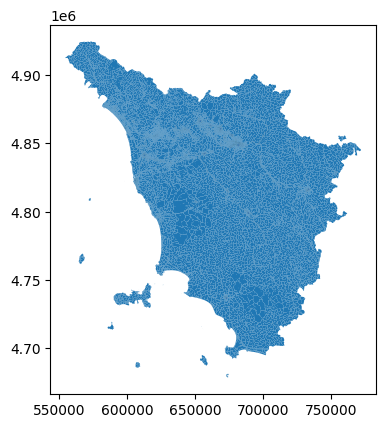

In [21]:
gdf.plot();

In [3]:
gdf[gdf['SEZ21_ID'] == 460068888888]

,COD_REG,COD_UTS,PRO_COM,SEZ21,SEZ21_ID,COD_TIPO_S,TIPO_LOC,LOC21_ID,COD_ZIC,COD_ISAM,...,COD_MONT_D,COD_AREA_S,COM_ASC1,COM_ASC2,COM_ASC3,POP21,FAM21,SHAPE_Leng,SHAPE_Area,geometry
3749,9,46,46006,8888888,460068888888,100,1,4600610001,0,0,...,0,0,0,0,0,0,0,48.012952,142.5294,"POLYGON ((606635.857 4890305.708, 606635.857 4..."


In [15]:
gdf.columns

Index(['COD_REG', 'COD_UTS', 'PRO_COM', 'SEZ21', 'SEZ21_ID', 'COD_TIPO_S',
       'TIPO_LOC', 'LOC21_ID', 'COD_ZIC', 'COD_ISAM', 'COD_ACQUE', 'COD_ISOLE',
       'COD_MONT_D', 'COD_AREA_S', 'COM_ASC1', 'COM_ASC2', 'COM_ASC3', 'POP21',
       'FAM21', 'SHAPE_Leng', 'SHAPE_Area', 'geometry'],
      dtype='str')

In [24]:
gdf[gdf['SEZ21'] == 48]

,COD_REG,COD_UTS,PRO_COM,SEZ21,SEZ21_ID,COD_TIPO_S,TIPO_LOC,LOC21_ID,COD_ZIC,COD_ISAM,...,COD_MONT_D,COD_AREA_S,COM_ASC1,COM_ASC2,COM_ASC3,POP21,FAM21,SHAPE_Leng,SHAPE_Area,geometry
47,9,45,45001,48,450010000048,1,2,4500126614,0,0,...,0,0,0,0,0,10,5,388.586616,6.630367e+03,"POLYGON ((581299.294 4898955.509, 581304.466 4..."
184,9,45,45002,48,450020000048,1,1,4500210007,0,0,...,0,0,0,0,0,40,26,2098.576146,4.757850e+04,"POLYGON ((582667.71 4909395.799, 582669.431 49..."
282,9,45,45003,48,450030000048,1,1,4500310003,0,0,...,0,0,45003002,0,0,147,70,521.335866,1.260727e+04,"POLYGON ((588567.046 4880919.54, 588458.16 488..."
729,9,45,45006,48,450060000048,1,1,4500610004,0,0,...,0,0,0,0,0,0,0,504.288271,4.803330e+03,"POLYGON ((573436.618 4909527.677, 573420.531 4..."
835,9,45,45007,48,450070000048,1,2,4500726616,0,0,...,0,0,0,0,0,14,6,465.357783,7.989494e+03,"POLYGON ((587848.186 4896765.826, 587851.558 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45115,9,53,53024,48,530240000048,22,4,5302440001,0,0,...,0,0,0,0,0,13,4,9224.936107,3.639380e+06,"POLYGON ((645766.77 4746693.924, 645786.297 47..."
45253,9,53,53026,48,530260000048,1,1,5302610006,0,0,...,0,0,0,0,0,195,109,2915.086900,1.172183e+05,"POLYGON ((726683.986 4727750.195, 726672.486 4..."
45353,9,53,53027,48,530270000048,26,4,5302740001,0,0,...,0,0,0,0,0,0,0,1598.544328,5.243325e+04,"POLYGON ((645414.672 4779805.488, 645447.675 4..."
45785,9,100,100004,48,1000040000048,64,4,10000440001,0,0,...,0,0,0,0,0,50,23,12809.608372,1.868586e+06,"POLYGON ((663707.309 4854836.2, 663706.809 485..."
